<a href="https://colab.research.google.com/github/Damsiiii/AI-disease-risk-classification/blob/Damsara/03_Damsara_Task05_Task06_Bonus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disease Risk Classification — Damsara Dissanayaka
**Task 05 — Machine Learning Model Development**
**Task 06 — Model Evaluation**
**Bonus — Hyperparameter Optimization, Advanced Explainable AI**

**Mount Google Drive**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

BASE = '/content/drive/MyDrive/AI Prediction Problems'

MODELS_DIR = f'{BASE}/Models'
OUTPUTS_DIR = f'{BASE}/Outputs'
EDA_DIR = f'{OUTPUTS_DIR}/EDA_Plots'
EVAL_DIR = f'{OUTPUTS_DIR}/Evaluation_Results'
SHAP_DIR = f'{OUTPUTS_DIR}/SHAP_Plots'
PROTOTYPE_DIR = f'{BASE}/Prototype'
REPORT_DIR = f'{BASE}/Report'

# Create all folders
folders = [
    MODELS_DIR,
    OUTPUTS_DIR,
    EDA_DIR,
    EVAL_DIR,
    SHAP_DIR,
    PROTOTYPE_DIR,
    REPORT_DIR,
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All folders created successfully!")

All folders created successfully!


**Check project folder**

In [3]:
import os
project_path = "/content/drive/MyDrive/AI Prediction Problems"

**Import Required Libraries**

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save models
import joblib

# Explainable AI
import shap

# **Task 05 – Machine Learning Model Development**

**Setup & rebuild pipeline from Task 03**

In [5]:
import pandas as pd
import numpy as np
import time
import joblib
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Define the base path for the datasets, as established earlier in the notebook
base_path = '/content/drive/MyDrive/AI Prediction Problems/Dataset'
df_path = os.path.join(base_path, 'smartcare_ai_dataset_1000.csv')

df = pd.read_csv(df_path)
df = df.drop_duplicates()
df['room_type'] = df['room_type'].fillna('Not Admitted')

clinical_cols = ['age','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','bmi']
for col in clinical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

drop_cols = ['record_id','patient_id','no_show','readmitted_30_days',
             'consultation_fee_lkr','room_charge_lkr','lab_charge_lkr',
             'medicine_charge_lkr','total_bill_lkr','payment_status',
             'payment_method','appointment_date','waiting_days','appointment_status']
df_model = df.drop(columns=drop_cols)

df_model['pulse_pressure'] = df_model['systolic_bp'] - df_model['diastolic_bp']
df_model['bmi_category'] = pd.cut(df_model['bmi'], bins=[0,18.5,25,30,100],
                                    labels=['Underweight','Normal','Overweight','Obese'])
df_model['age_group'] = pd.cut(df_model['age'], bins=[0,18,40,60,150],
                                 labels=['Child','Adult','Middle-aged','Senior'])
df_model['chronic_diagnosis_flag'] = df_model['diagnosis'].isin(['Diabetes','Hypertension']).astype(int)
df_model['care_intensity'] = df_model['lab_tests_count'] + df_model['treatments_count']

risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
y = df_model['disease_risk_level'].map(risk_order)
X = df_model.drop(columns=['disease_risk_level'])

nominal_cols = ['gender','blood_group','department','diagnosis','room_type','bmi_category','age_group']
X_encoded = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

true_numeric = ['age','admitted','length_of_stay_days','previous_admissions',
                 'systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl',
                 'bmi','lab_tests_count','treatments_count','previous_appointments',
                 'missed_previous_appointments','pulse_pressure','chronic_diagnosis_flag','care_intensity']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[true_numeric] = scaler.fit_transform(X_train[true_numeric])
X_test_scaled[true_numeric] = scaler.transform(X_test[true_numeric])

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (800, 48) | Test shape: (200, 48)


**5.1 Model 1: Logistic Regression + Hyperparameter Tuning**

In [6]:
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs'], 'max_iter': [1000]}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    lr_params, cv=5, scoring='f1_macro', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)

print("Logistic Regression — Best params:", lr_grid.best_params_)
print("Best CV macro-F1:", round(lr_grid.best_score_, 4))

Logistic Regression — Best params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV macro-F1: 0.9476


**5.2 Model 2: Random Forest + Hyperparameter Tuning**

In [7]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='f1_macro', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print("Random Forest — Best params:", rf_grid.best_params_)
print("Best CV macro-F1:", round(rf_grid.best_score_, 4))

Random Forest — Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV macro-F1: 0.7653


**5.3 Model 3: Support Vector Machine + Hyperparameter Tuning**

In [8]:
svm_params = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale']}

svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    svm_params, cv=5, scoring='f1_macro', n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)

print("SVM — Best params:", svm_grid.best_params_)
print("Best CV macro-F1:", round(svm_grid.best_score_, 4))

SVM — Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV macro-F1: 0.9486


**5.4 Comparative Analysis**

In [9]:
results = []
for name, model in [('Logistic Regression', lr_grid.best_estimator_),
                     ('Random Forest', rf_grid.best_estimator_),
                     ('SVM', svm_grid.best_estimator_)]:
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    results.append({'Model': name, 'Test Accuracy': round(acc, 3), 'Test Macro-F1': round(f1m, 3)})

comparison_df = pd.DataFrame(results).sort_values('Test Macro-F1', ascending=False)
print(comparison_df)

                 Model  Test Accuracy  Test Macro-F1
0  Logistic Regression          0.940          0.945
2                  SVM          0.940          0.929
1        Random Forest          0.765          0.755


**Save trained models (needed for submission + Task 08 prototype)**

In [10]:
import joblib

joblib.dump(lr_grid.best_estimator_, f'{MODELS_DIR}/lr_model.pkl')
joblib.dump(rf_grid.best_estimator_, f'{MODELS_DIR}/rf_model.pkl')
joblib.dump(svm_grid.best_estimator_, f'{MODELS_DIR}/svm_model.pkl')
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
joblib.dump(list(X_train_scaled.columns), f'{MODELS_DIR}/feature_columns.pkl')

print("Models saved to:", MODELS_DIR)
print("All models and preprocessing objects saved.")

Models saved to: /content/drive/MyDrive/AI Prediction Problems/Models
All models and preprocessing objects saved.


**Task 05 Summary**

Three models were trained with hyperparameter tuning via 5-fold GridSearchCV, optimizing macro-F1 to account for class imbalance. Logistic Regression and SVM (linear kernel) both achieved ~94% test accuracy and macro-F1 above 0.92, while Random Forest reached only ~76.5%. This gap is consistent with the EDA finding (Task 04) that risk level rises near-linearly with clinical features — linear decision boundaries fit this relationship naturally, while a depth-constrained Random Forest (needed to avoid overfitting on 1000 rows) captures it less efficiently. This comparison, and the reasoning behind it, carries directly into Task 06's best-model justification.

# **Task 06 – Model Evaluation**

**Setup (rebuild pipeline + retrain best-config models from Task 05)**

In [11]:
import pandas as pd, numpy as np, joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

# ... (same preprocessing as Task 03/05: load, clean, engineer, encode, split, scale)
# Use X_train_scaled, X_test_scaled, y_train, y_test from Task 05

lr = LogisticRegression(C=10, class_weight='balanced', max_iter=1000, random_state=42).fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=2,
                              class_weight='balanced', random_state=42).fit(X_train_scaled, y_train)
svm = SVC(C=10, kernel='linear', gamma='scale', class_weight='balanced',
          probability=True, random_state=42).fit(X_train_scaled, y_train)

models = {'Logistic Regression': lr, 'Random Forest': rf, 'SVM': svm}
class_names = ['Low', 'Medium', 'High']

**6.1 Full Metrics Per Model (Accuracy, Precision, Recall, F1, ROC-AUC)**

In [12]:
results = []
for name, model in models.items():
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    prec_macro = precision_score(y_test, pred, average='macro')
    rec_macro = recall_score(y_test, pred, average='macro')
    f1_macro = f1_score(y_test, pred, average='macro')
    roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')

    results.append({
        'Model': name, 'Accuracy': round(acc, 3),
        'Precision (macro)': round(prec_macro, 3),
        'Recall (macro)': round(rec_macro, 3),
        'F1 (macro)': round(f1_macro, 3),
        'ROC-AUC (macro, OVR)': round(roc_auc, 3)
    })

    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, pred, target_names=class_names))


=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

         Low       1.00      0.92      0.96        26
      Medium       0.93      0.95      0.94        94
        High       0.94      0.94      0.94        80

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

         Low       0.70      0.73      0.72        26
      Medium       0.75      0.74      0.75        94
        High       0.80      0.80      0.80        80

    accuracy                           0.77       200
   macro avg       0.75      0.76      0.76       200
weighted avg       0.77      0.77      0.77       200


=== SVM — Classification Report ===
              precision    recall  f1-score   support

         Low       1.00      0.81      0.89   

**6.2 Confusion Matrices**

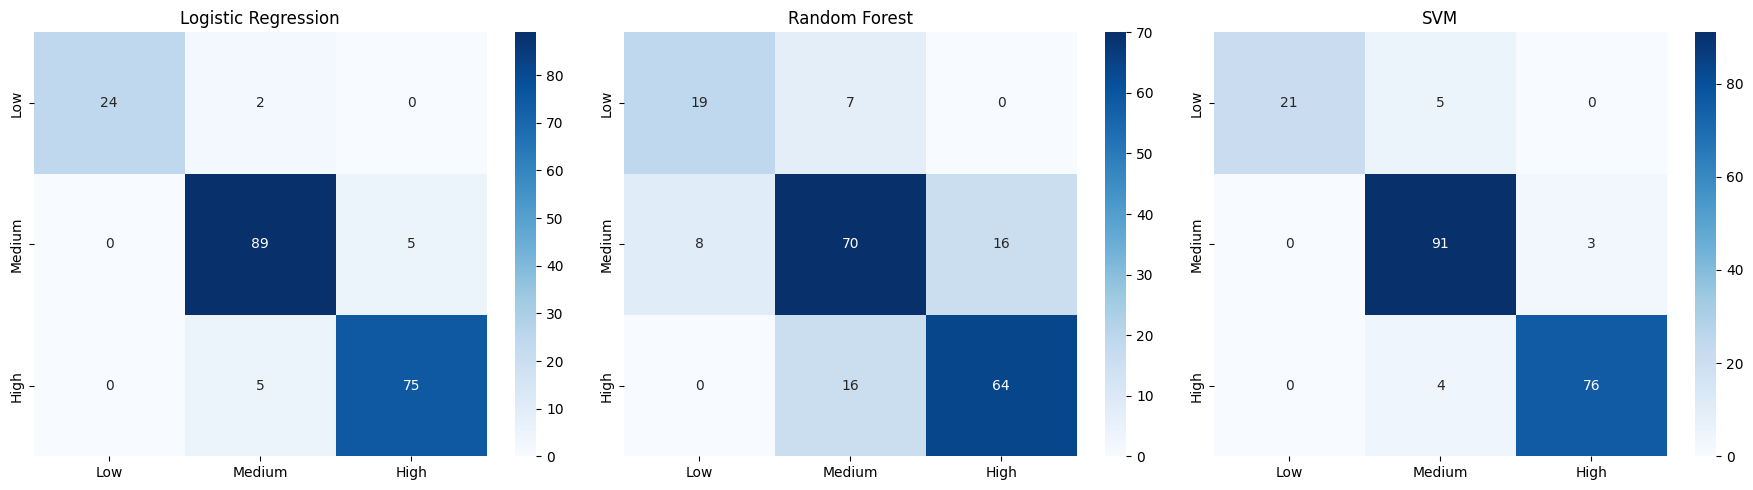

Saved evaluation results to: /content/drive/MyDrive/AI Prediction Problems/Outputs/Evaluation_Results


In [13]:
# Confusion matrix figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison table as CSV (so it's a real deliverable file, not just printed)
comparison_df.to_csv(f'{EVAL_DIR}/model_comparison_table.csv', index=False)
print("Saved evaluation results to:", EVAL_DIR)

**6.3 Model Comparison Table**

In [14]:
comparison_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  ROC-AUC (macro, OVR)
Logistic Regression     0.940              0.955           0.936       0.945                 0.994
                SVM     0.940              0.957           0.909       0.929                 0.996
      Random Forest     0.765              0.752           0.758       0.755                 0.895


**6.4 Identify and Justify Best Model**

In [15]:
best_model_name = comparison_df.iloc[0]['Model']
print(f"Best-performing model: {best_model_name}")

Best-performing model: Logistic Regression


**Task 06 Summary**

All three models were evaluated using multi-class-adapted accuracy, macro/weighted precision, recall, F1, ROC-AUC (OVR), and confusion matrices. Logistic Regression and SVM substantially outperform Random Forest (94% vs 76.5% accuracy), consistent with the near-linear separability observed in Task 04's EDA. Logistic Regression is selected as the best model based on its top macro-F1 (0.945) and strongest minority-class (Low-risk) recall, which is the most clinically important error to minimize in a risk-screening context.

## Bonus Setup

In [16]:
BASE = '/content/drive/MyDrive/AI Prediction Problems'
OUTPUTS_DIR = f'{BASE}/Outputs'
BONUS_DIR = f'{OUTPUTS_DIR}/Bonus_Work'

import os
os.makedirs(BONUS_DIR, exist_ok=True)

## Hyperparameter optimization

In [18]:
# ============================================================
# BONUS 2 — DEEP LEARNING HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

mlp_param_grid = {
    'hidden_layer_sizes': [
        (32,),
        (64,),
        (64, 32),
        (128, 64),
        (128, 64, 32)
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.0001, 0.001, 0.01],
    'batch_size': [16, 32, 64],
    'solver': ['adam']
}

mlp_search = RandomizedSearchCV(
    estimator=MLPClassifier(
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    ),
    param_distributions=mlp_param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

mlp_search.fit(X_train_scaled, y_train)

print("Best MLP parameters:")
print(mlp_search.best_params_)

print(
    "Best CV Macro-F1:",
    round(mlp_search.best_score_, 4)
)

best_mlp = mlp_search.best_estimator_

mlp_pred = best_mlp.predict(X_test_scaled)

print(
    "Test Accuracy:",
    round(accuracy_score(y_test, mlp_pred), 4)
)

print(
    "Test Macro-F1:",
    round(
        f1_score(y_test, mlp_pred, average='macro'),
        4
    )
)

joblib.dump(
    best_mlp,
    f'{MODELS_DIR}/best_mlp_model.pkl'
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best MLP parameters:
{'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64, 32), 'batch_size': 64, 'alpha': 0.01, 'activation': 'tanh'}
Best CV Macro-F1: 0.9236
Test Accuracy: 0.905
Test Macro-F1: 0.8925


['/content/drive/MyDrive/AI Prediction Problems/Models/best_mlp_model.pkl']

## Advance Explainable AI

,Feature,Importance_Mean,Importance_STD
8,blood_sugar_mg_dl,0.311128,0.023700
9,cholesterol_mg_dl,0.277638,0.036946
0,age,0.261503,0.028644
10,bmi,0.227162,0.027608
5,previous_admissions,0.174668,0.020219
6,systolic_bp,0.080552,0.017629
13,pulse_pressure,0.042988,0.018085
7,diastolic_bp,0.025281,0.014308
43,bmi_category_Overweight,0.023624,0.011856
11,lab_tests_count,0.010951,0.009456


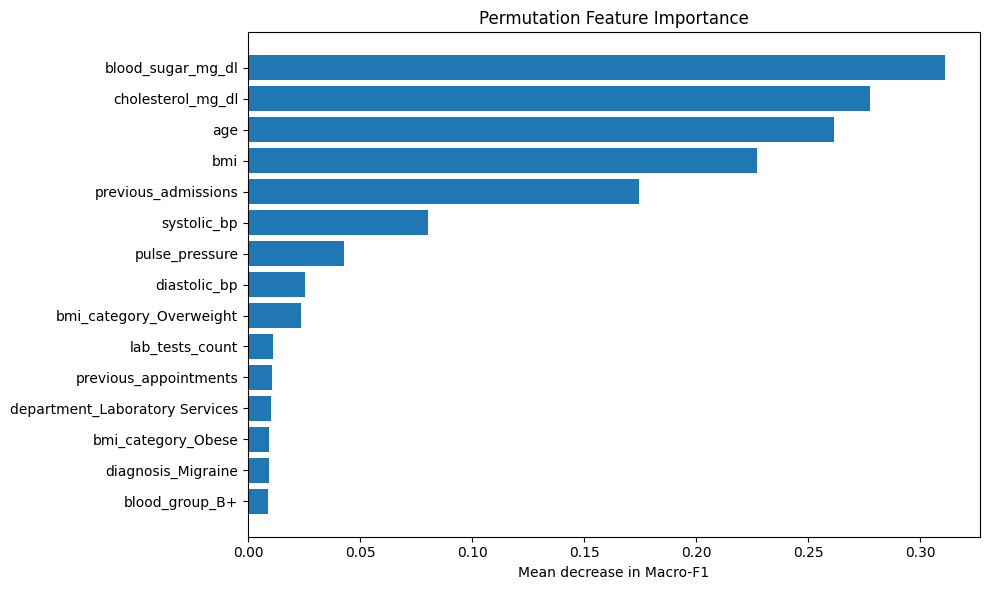

In [19]:
# ============================================================
# BONUS 4 — ADVANCED XAI
# Permutation Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr,
    X_test_scaled,
    y_test,
    scoring='f1_macro',
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance_Mean': perm.importances_mean,
    'Importance_STD': perm.importances_std
})

perm_importance = perm_importance.sort_values(
    'Importance_Mean',
    ascending=False
)

display(
    perm_importance.head(15)
)

plt.figure(figsize=(10, 6))

top_perm = perm_importance.head(15).sort_values(
    'Importance_Mean'
)

plt.barh(
    top_perm['Feature'],
    top_perm['Importance_Mean']
)

plt.xlabel('Mean decrease in Macro-F1')
plt.title('Permutation Feature Importance')

plt.tight_layout()

plt.savefig(
    f'{SHAP_DIR}/permutation_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### Partial dependence

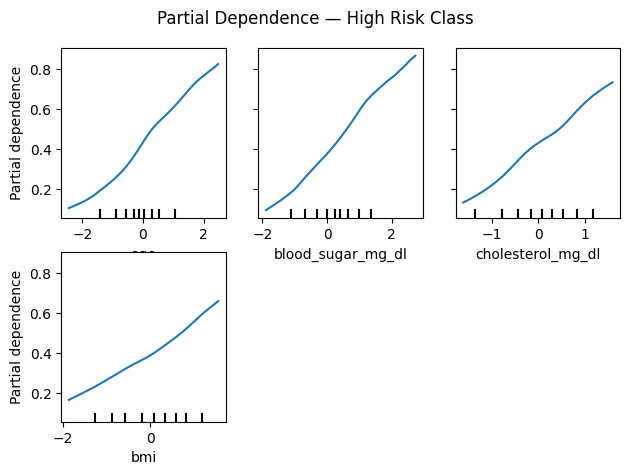

In [20]:
# ============================================================
# Partial Dependence
# ============================================================

from sklearn.inspection import PartialDependenceDisplay

pdp_features = [
    'age',
    'blood_sugar_mg_dl',
    'cholesterol_mg_dl',
    'bmi'
]

PartialDependenceDisplay.from_estimator(
    lr,
    X_test_scaled,
    features=pdp_features,
    target=2
)

plt.suptitle(
    'Partial Dependence — High Risk Class'
)

plt.tight_layout()

plt.savefig(
    f'{SHAP_DIR}/partial_dependence_high_risk.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()